# 3 · Out-of-sample check and audit
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/NBA-Analysis/blob/main/notebooks/03_out_of_sample_audit.ipynb)

The report's headline (*the random forest picks the league leader in 13 of 20 seasons*) is computed with a model
trained on those same 20 seasons. This notebook asks the question a forecaster cares about:
**how well does the method do on a season it has never seen?**

- **Walk-forward test**: for each season 2010-2025, train only on earlier seasons, then predict that season from its own box scores. This measures fit on unseen seasons, not pre-season forecasting (the season's stats are not known in advance).
- **Reference**: "every team repeats last season's win %". It only uses pre-season information, so it is a point of scale, not a fair benchmark.
- **Corrected data**: re-run everything with the cleaning fixes from the audit log at the bottom.

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/NBA-Analysis
    %cd NBA-Analysis/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
import pandas as pd
from nba import plots
from nba.data import build_datasets, CORRECTED
plots.use_style()
pd.set_option("display.precision", 3)
from sklearn.linear_model import LinearRegression
from nba import model as m

In [2]:
FIRST = 2010
rows = {}
for label, options in [("report cleaning", {}), ("corrected", CORRECTED)]:
    players, standings = build_datasets(**options)
    rf_table = m.rf_team_table(players, standings)
    in_sample = rf_table.copy()
    in_sample["W%_pred"] = m.rf_model().fit(m.rf_features(rf_table), rf_table["W%"]).predict(m.rf_features(rf_table))
    rows[f"Random forest, in-sample ({label})"] = m.summarize(in_sample[in_sample.Season >= FIRST])
    rows[f"Random forest, walk-forward ({label})"] = m.summarize(m.walk_forward(rf_table, first_test_season=FIRST))
    ols_table = m.ols_team_table(players, standings)
    rows[f"OLS, walk-forward ({label})"] = m.summarize(
        m.walk_forward(ols_table, features=m.ols_features, make_model=LinearRegression, first_test_season=FIRST))

base = standings[["Team", "Season", "W%", "Rk"]].copy()
prev = base[["Team", "Season", "W%"]].assign(Season=lambda d: d.Season + 1).rename(columns={"W%": "W%_pred"})
base = base.merge(prev, on=["Team", "Season"])
rows["Baseline: repeat last season"] = m.summarize(base[base.Season >= FIRST])

results = pd.DataFrame(rows).T
results.round(3).to_csv("../reports/evaluation.csv")
results.round(3)

,R2,MAE_wins,Rank_MAE,Leader_hits,Seasons,Leader_top3
"Random forest, in-sample (report cleaning)",0.893,3.265,2.133,11.0,16.0,16.0
"Random forest, walk-forward (report cleaning)",0.419,7.492,5.396,3.0,16.0,10.0
"OLS, walk-forward (report cleaning)",0.503,7.029,4.442,7.0,16.0,12.0
"Random forest, in-sample (corrected)",0.894,3.281,2.162,12.0,16.0,16.0
"Random forest, walk-forward (corrected)",0.417,7.495,5.583,4.0,16.0,9.0
"OLS, walk-forward (corrected)",0.499,7.078,4.521,7.0,16.0,12.0
Baseline: repeat last season,0.229,8.409,5.733,5.0,16.0,8.0


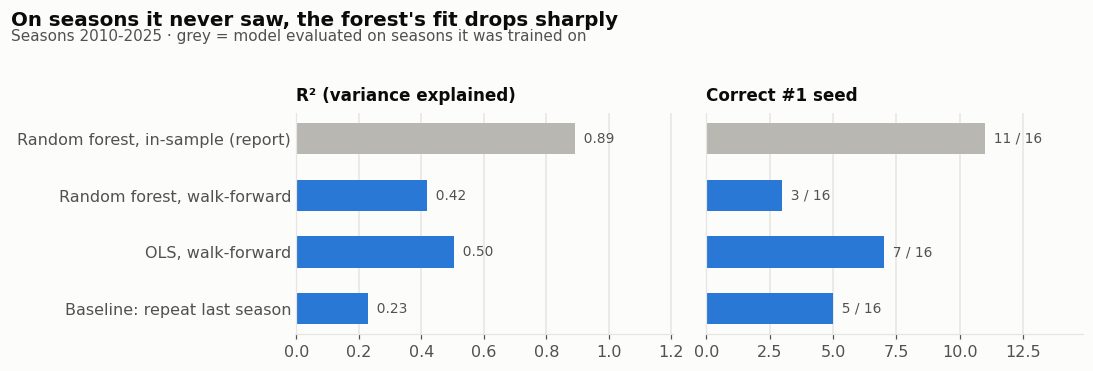

In [3]:
chart = results.loc[["Random forest, in-sample (report cleaning)", "Random forest, walk-forward (report cleaning)",
                     "OLS, walk-forward (report cleaning)", "Baseline: repeat last season"]]
chart.index = ["Random forest, in-sample (report)", "Random forest, walk-forward",
               "OLS, walk-forward", "Baseline: repeat last season"]
fig = plots.evaluation(chart, seasons=f"{FIRST}-2025"); plots.save(fig, "evaluation");

**Reading the table**
- In-sample, the forest explains ~89% of win % and picks 11 of 16 leaders. It is largely recalling seasons it trained on.
- Walk-forward, it explains ~42% and picks 3 of 16. The simpler **OLS generalises better** (R² ≈ 0.50, 7 of 16).
- Both models beat the repeat-last-season reference (R² ≈ 0.23), but they see the season's own box scores and the reference does not, so this is not evidence of forecasting skill.
- The cleaning fixes move these results by less than the season-to-season noise.

This flips one of the report's conclusions (random forest > OLS). Choosing the model with a time-based test, and backtesting the full projection pipeline, are the first things to change in a v2.

## Audit log: issues found while porting the original notebooks

| Issue | Effect | Fix |
|---|---|---|
| 2026 roster names didn't match the history (whitespace, typos, accents) | 36 established players, including Wembanyama, Towns and Bridges, projected with the rookie line (118 of 522 unmatched in all; the other 82 are genuine newcomers) | `load_roster_2026(match_names=True)` |
| Projection regressions trained on the all-zero 2026 rows | projected stats biased toward 0 | `forecast_2026(fixes=True)` |
| Missing lag seasons filled with 0 | 2nd/3rd-year players under-projected | `fixes=True` (reuse latest season) |
| "Points per attempt" averaged players' shooting % | non-shooters count as 0% from three; twos looked better every season | `expected_points(weighted=True)` |
| Multi-team total rows and "League Average" kept as a pseudo-team `0` | league-wide averages double-count traded players (+171% vs +175% 3PA growth) | `aggregates="drop"` |
| TS% coded as `PTS / (2·FGA + 0.44·FTA)` | TS% inflated (should be `PTS / (2·(FGA + 0.44·FTA))`) | `ts_formula="standard"` |
| Lagged awards via `groupby(Player).shift(1)` | for traded players the "previous season" can be the same season | `lag="season"` |
| Winner filter excludes strings containing `DPOY-10` | 2025 MVP (SGA, `MVP-1DPOY-10…`) not flagged; patched by hand in the forecast | `awards="parsed"` |
| `DPOY` dummy also matches `DEF` | All-Defensive selections counted as DPOY votes | `awards="parsed"` |
| Ties in W% ranked by sort order | 2012 CHI/SAS (50-16) could swap | ranks use Basketball-Reference `Rk` (always on) |
| 21 names in `rs2024.csv` have `?` for accented letters | those players lose their 2024 → 2025 award lag | not fixed (source file); `name_key` matching would be the fix |
| Players matched by name only | two players with the same name would merge | not fixed; Basketball-Reference IDs (`Player-additional`) would be the fix |